In [ ]:
# Import bibliotek 
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# Wczytanie danych 
df = pd.read_csv("ai_student_impact_dataset.csv")

In [72]:
# Sprawdzenie poprawności danych
def missing_values(df):
    headers = ["Coumns names", "Number of missing data"]
    records = []
    for column in df.columns:
        records.append([column, df[column].isna().sum()])
    print(tabulate(records, headers = headers))

missing_values(df)

Coumns names                  Number of missing data
--------------------------  ------------------------
Student_ID                                         0
Major_Category                                     0
Year_of_Study                                      0
Pre_Semester_GPA                                   0
Weekly_GenAI_Hours                                 0
Primary_Use_Case                                   0
Prompt_Engineering_Skill                           0
Tool_Diversity                                     0
Paid_Subscription                                  0
Traditional_Study_Hours                            0
Perceived_AI_Dependency                            0
Institutional_Policy                               0
Anxiety_Level_During_Exams                         0
Post_Semester_GPA                                  0
Skill_Retention_Score                              0
Burnout_Risk_Level                                 0


In [121]:
# Nazwy kolumn i rodzaje danych 
def types_of_data(df):
    # kolumny
    headers = ["Columns names", "Types of data"]
    records = []
    for index, column in enumerate(df.columns):
        records.append([column, type(df.iloc[0,index])])
    print(tabulate(records, headers = headers))

types_of_data(df)


Columns names               Types of data
--------------------------  -----------------------
Student_ID                  <class 'numpy.int64'>
Major_Category              <class 'str'>
Year_of_Study               <class 'str'>
Pre_Semester_GPA            <class 'numpy.float64'>
Weekly_GenAI_Hours          <class 'numpy.float64'>
Primary_Use_Case            <class 'str'>
Prompt_Engineering_Skill    <class 'str'>
Tool_Diversity              <class 'numpy.int64'>
Paid_Subscription           <class 'numpy.bool'>
Traditional_Study_Hours     <class 'numpy.float64'>
Perceived_AI_Dependency     <class 'numpy.int64'>
Institutional_Policy        <class 'str'>
Anxiety_Level_During_Exams  <class 'numpy.int64'>
Post_Semester_GPA           <class 'numpy.float64'>
Skill_Retention_Score       <class 'numpy.float64'>
Burnout_Risk_Level          <class 'str'>


In [74]:
# Przykładowy rekord z bazy
df.iloc[0]

Student_ID                                   100001
Major_Category                           Humanities
Year_of_Study                                Senior
Pre_Semester_GPA                              2.418
Weekly_GenAI_Hours                            23.31
Primary_Use_Case               Copywriting/Drafting
Prompt_Engineering_Skill                   Beginner
Tool_Diversity                                    1
Paid_Subscription                              True
Traditional_Study_Hours                        8.13
Perceived_AI_Dependency                           5
Institutional_Policy          Allowed_With_Citation
Anxiety_Level_During_Exams                        6
Post_Semester_GPA                             2.393
Skill_Retention_Score                         86.44
Burnout_Risk_Level                             High
Name: 0, dtype: object

In [125]:
# Statystyki poszczególnych kolumn w bazie danych
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


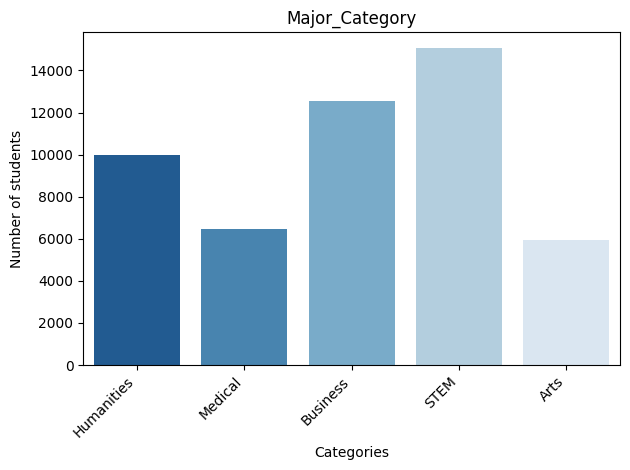

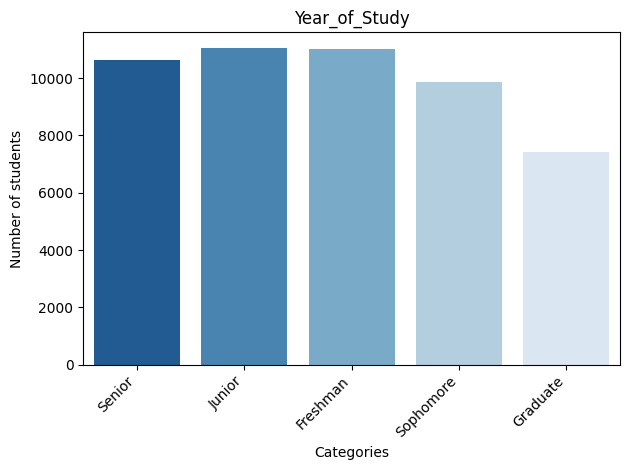

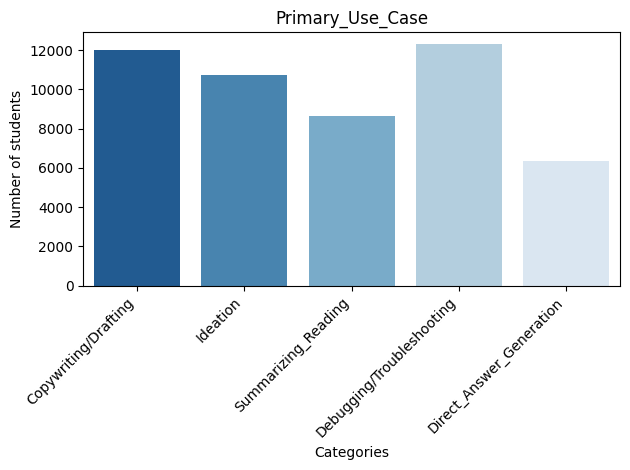

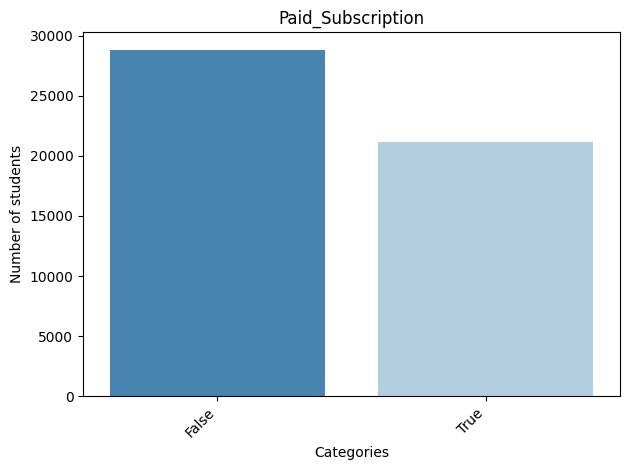

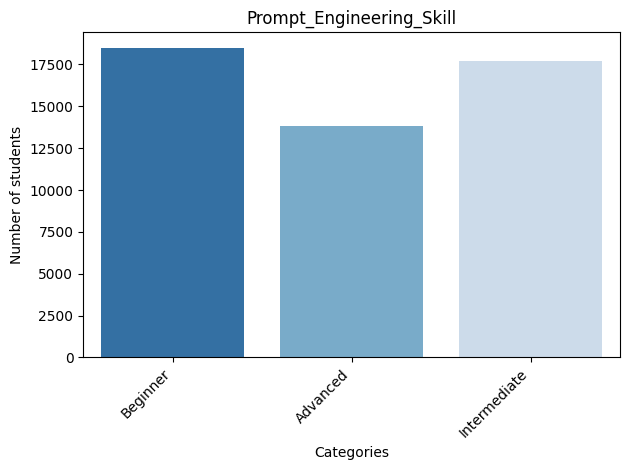

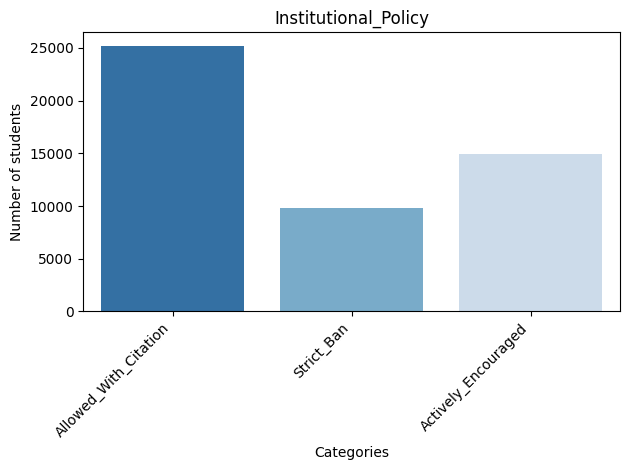

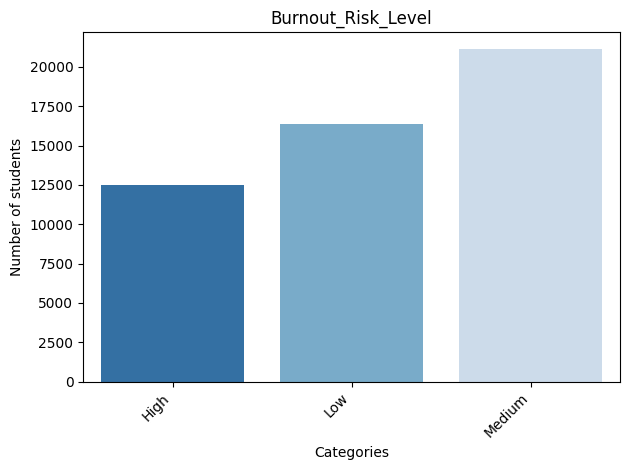

In [ ]:
# Ilustracja danych - które są tekstem lub boolem
def data_illustration1(df):
    column_names= ["Major_Category", "Year_of_Study", "Primary_Use_Case","Paid_Subscription",
                    "Prompt_Engineering_Skill", "Institutional_Policy", "Burnout_Risk_Level"]
    for column in column_names:
        sns.countplot(x=column, data=df, hue=column, palette="Blues_r", legend=False)

        plt.title(column)
        plt.xlabel("Categories")
        plt.xticks(rotation=45, ha="right")

        plt.ylabel("Number of students")
        plt.tight_layout()
        plt.show()


data_illustration1(df)

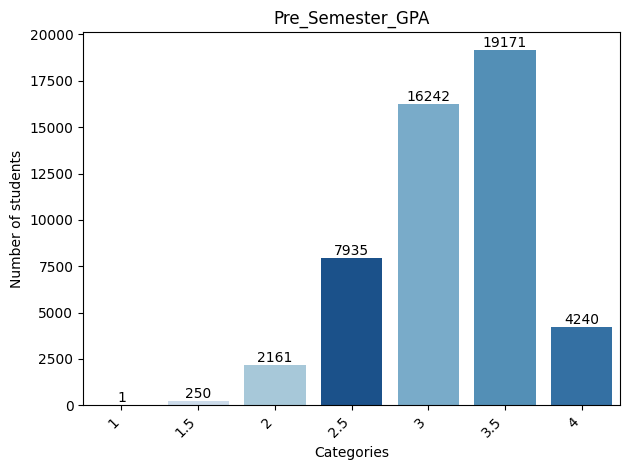

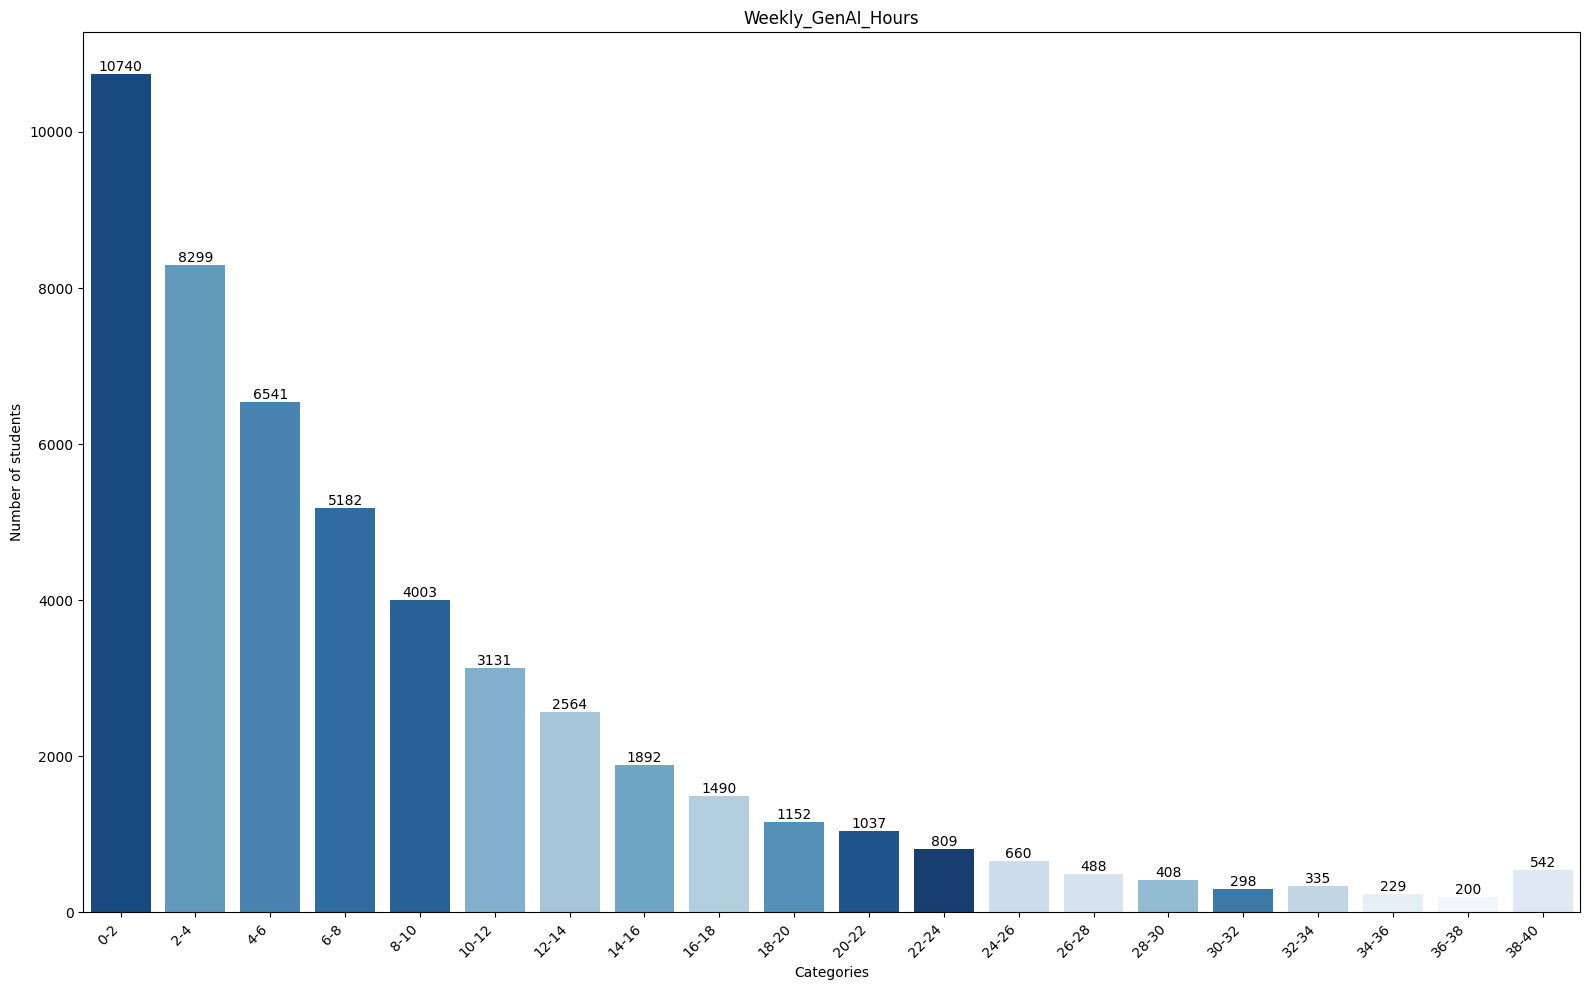

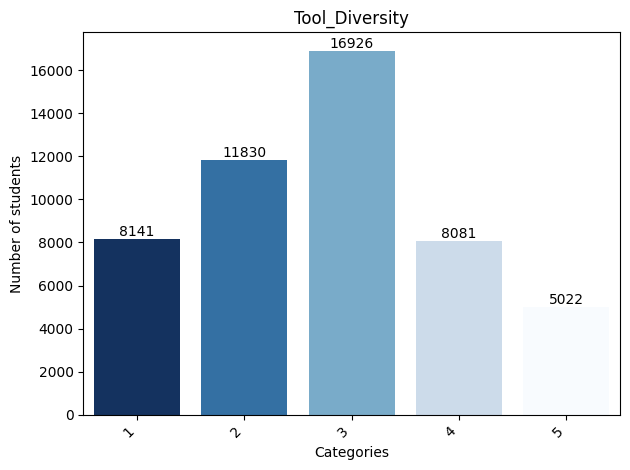

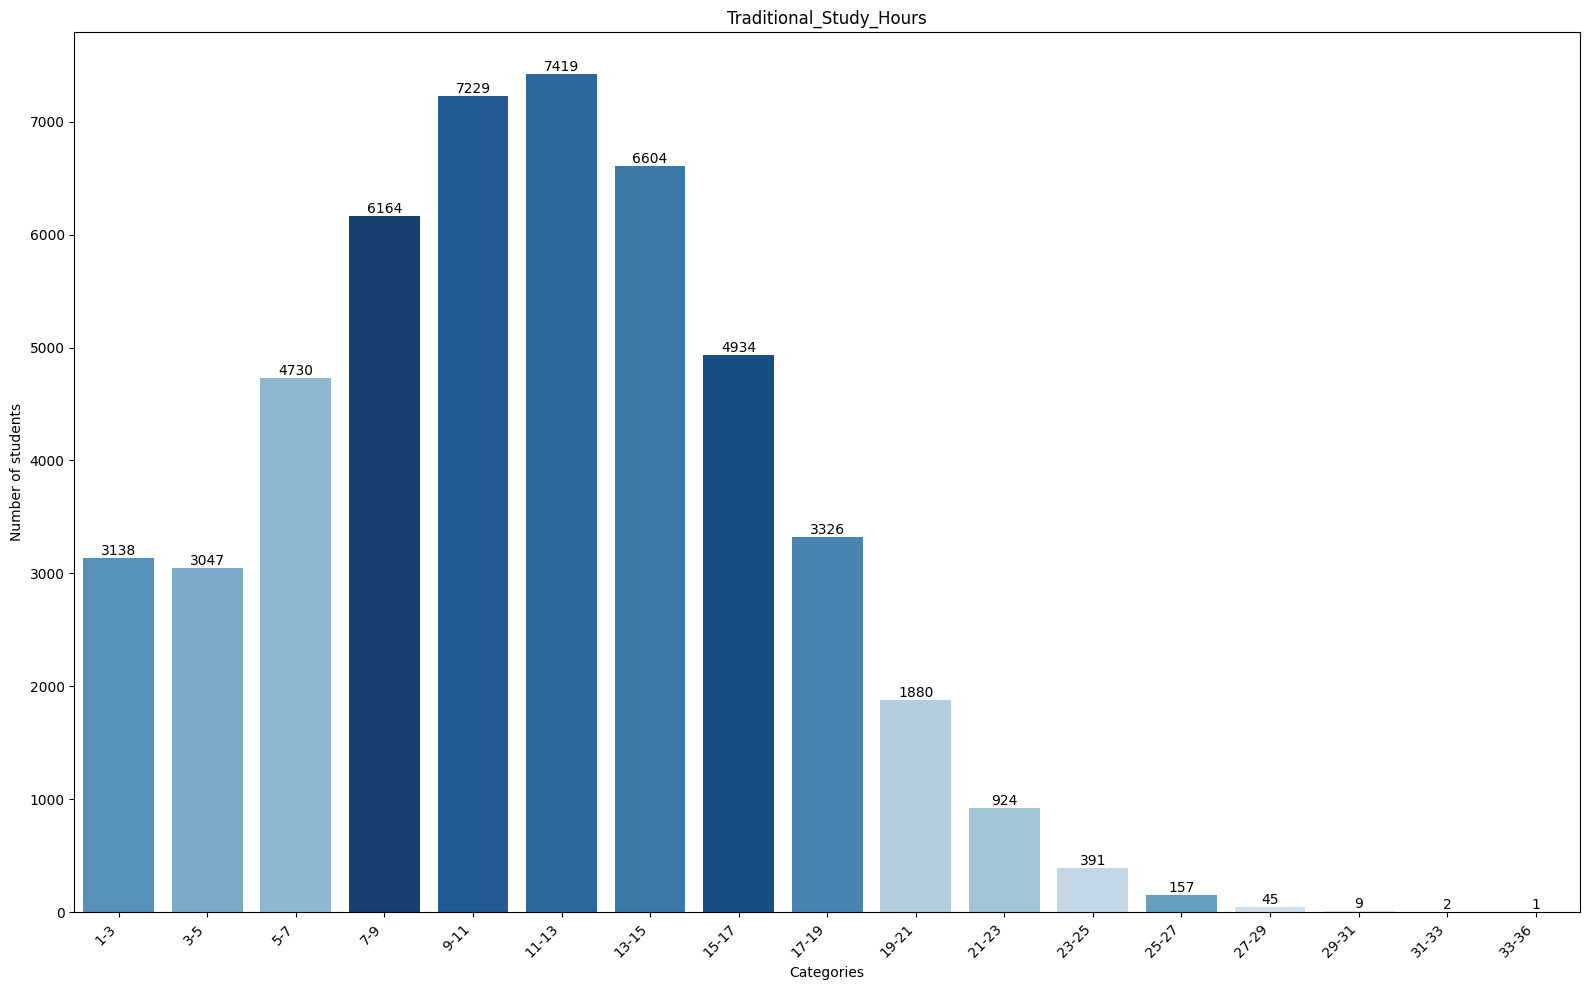

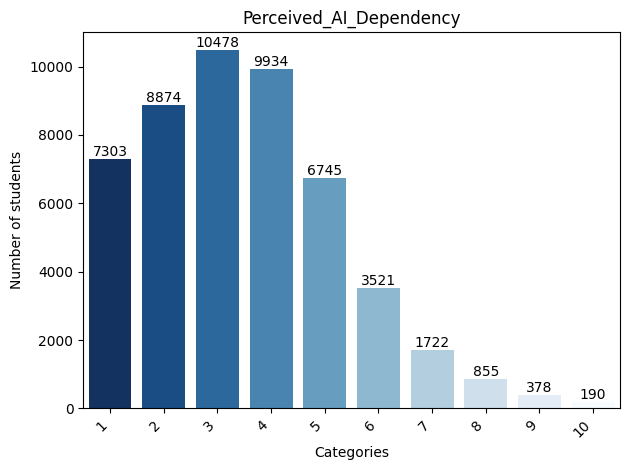

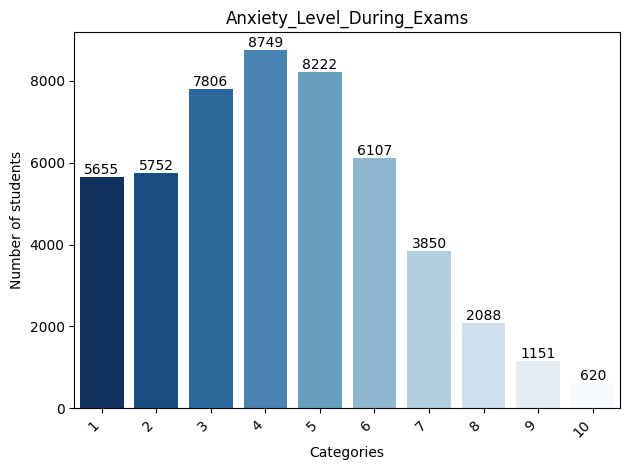

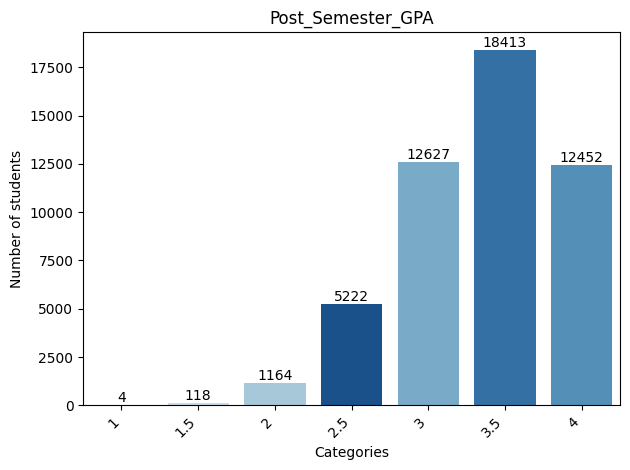

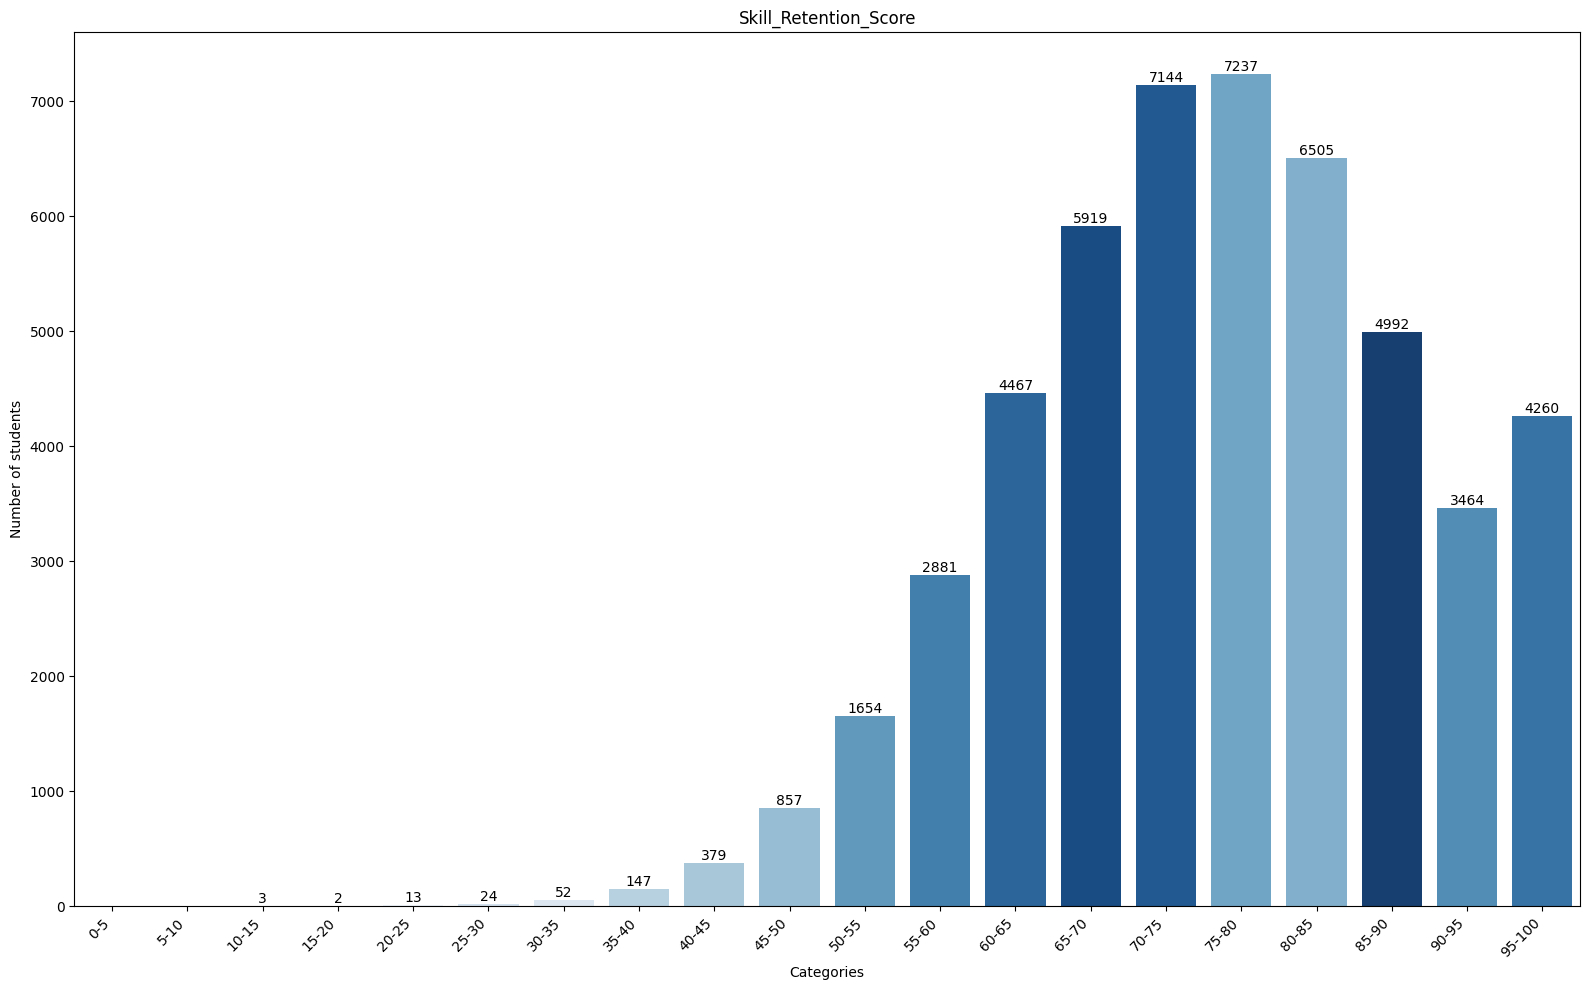

In [159]:
# Ilustracja danych - które są intem lub floatem
def data_illustration2(df):
    column_names= ["Pre_Semester_GPA","Weekly_GenAI_Hours", "Tool_Diversity", "Traditional_Study_Hours",
                    "Perceived_AI_Dependency", "Anxiety_Level_During_Exams",  "Post_Semester_GPA", "Skill_Retention_Score"]
    for column in column_names:
        # Ocena na początku semestru - dane są w floatach w zakresie (1.00 - 4.00)
        df_copy = df.copy()
        if column == "Pre_Semester_GPA" or column == "Post_Semester_GPA":
            groups = ["1", "1.5", "2", "2.5", "3", "3.5", "4"]    # grupowanie ocen według nowej skali
            limits = [1.0, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.0]

        if column == "Weekly_GenAI_Hours":
            groups = ["{}-{}".format(i, i+2) for i in range(0, 39, 2)]
            limits = [i for i in range(0, 42, 2)]
            plt.figure(figsize=(16, 10))

        if column == "Traditional_Study_Hours":
            groups = ["{}-{}".format(i, i+2) for i in range(1, 33, 2)] + ["33-36"]
            limits = [i for i in range(1, 35, 2)] + [36]
            plt.figure(figsize=(16, 10))
        
        if column == "Skill_Retention_Score":
            groups = ["{}-{}".format(i, i+5) for i in range(0, 100, 5)]
            limits = [i for i in range(0, 101, 5)]
            plt.figure(figsize=(16, 10))

        if column == "Tool_Diversity" or column == "Perceived_AI_Dependency" or column == "Anxiety_Level_During_Exams":
            ax = sns.countplot(x=column, data=df, hue=column, palette="Blues_r", legend=False)

        if column != "Tool_Diversity" and column != "Perceived_AI_Dependency" and column != "Anxiety_Level_During_Exams": 
            df_copy[column] = pd.cut(df_copy[column], bins=limits, labels=groups, include_lowest=True).astype(str)
            ax = sns.countplot(x=column, data=df_copy, hue=column, palette="Blues_r", legend=False, order=groups)
        
        # wyświetlanie etykiet
        for container in ax.containers:
            ax.bar_label(container)

        plt.title(column)
        plt.xlabel("Categories")
        plt.xticks(rotation=45, ha="right")

        plt.ylabel("Number of students")
        plt.tight_layout()
        plt.show()

data_illustration2(df)